# Drift Detection

Compare training data vs production (drift) data. Detect drift and measure impact on model performance.

## Imports

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
from evidently import Report
from evidently.presets import DataDriftPreset

sns.set_style('whitegrid')

## Load Model and Data

In [16]:
# Load saved model and scaler
model = joblib.load('../02_src/baseline_model.pkl')
scaler = joblib.load('../02_src/scaler.pkl')
print("Model and scaler loaded.")

Model and scaler loaded.


In [17]:
# Load training data
df_train = pd.read_csv('../01_data/creditcard.csv')
print(f"Training data: {df_train.shape[0]:,} rows")

Training data: 284,807 rows


In [18]:
# Load drift datasets
drift_files = [f'../01_data/drift_{i}.csv' for i in range(1, 6)]
drift_dfs = {}

for i, file in enumerate(drift_files, 1):
    drift_dfs[i] = pd.read_csv(file)
    print(f"Drift {i}: {drift_dfs[i].shape[0]:,} rows, {drift_dfs[i].shape[1]} columns")

Drift 1: 15,000 rows, 32 columns
Drift 2: 15,000 rows, 32 columns
Drift 3: 18,000 rows, 32 columns
Drift 4: 15,000 rows, 32 columns
Drift 5: 15,000 rows, 32 columns


## Quick Look at Drift Data

In [19]:
# Check if drift data has same columns as training
print("Training columns:", df_train.columns.tolist())
print("\nDrift 1 columns:", drift_dfs[1].columns.tolist())
print("\nColumns match:", df_train.columns.tolist() == drift_dfs[1].columns.tolist())

Training columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Drift 1 columns: ['day', 'Time', 'Amount', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Class']

Columns match: False


In [20]:
# Compare shapes and fraud ratios
print(f"{'Dataset':<15} {'Rows':>10} {'Fraud %':>10}")
print("-" * 37)
print(f"{'Training':<15} {df_train.shape[0]:>10,} {df_train['Class'].mean()*100:>10.2f}")
for i, df in drift_dfs.items():
    print(f"{'Drift ' + str(i):<15} {df.shape[0]:>10,} {df['Class'].mean()*100:>10.2f}")

Dataset               Rows    Fraud %
-------------------------------------
Training           284,807       0.17
Drift 1             15,000       0.19
Drift 2             15,000       0.16
Drift 3             18,000       0.52
Drift 4             15,000       0.17
Drift 5             15,000       2.00


### Findings
- Drift 1, 2, 4: Similar fraud ratio to training (~0.17%)
- Drift 3: 3x more fraud (0.52%)
- Drift 5: 12x more fraud (2.00%)

Drift 3 and 5 have target distribution shift. Drift 1, 2, 4 may have feature drift without target change.

## Compare Feature Distributions

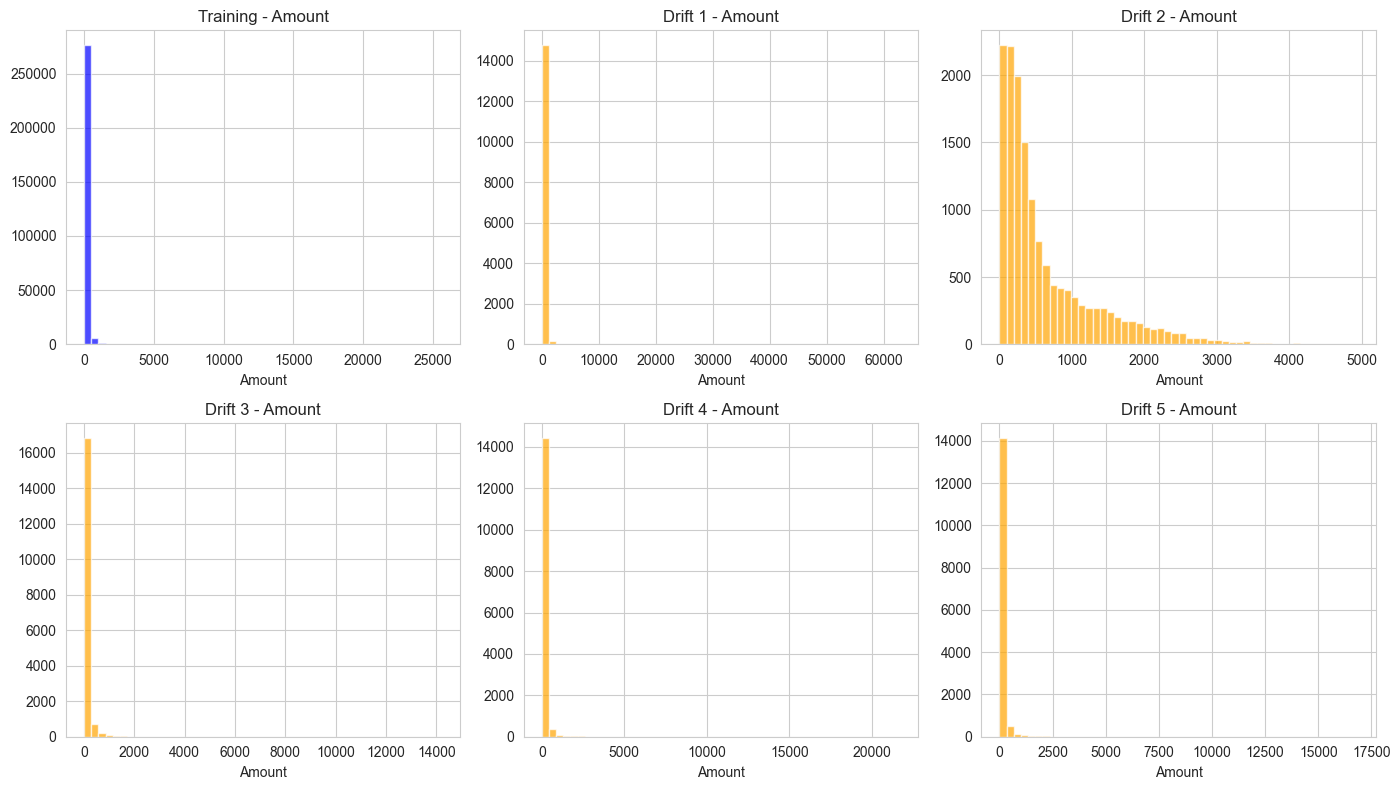

In [21]:
# Compare Amount distribution: training vs each drift set
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

# Training
axes[0].hist(df_train['Amount'], bins=50, alpha=0.7, color='blue')
axes[0].set_title('Training - Amount')
axes[0].set_xlabel('Amount')

# Drift sets
for i in range(1, 6):
    axes[i].hist(drift_dfs[i]['Amount'], bins=50, alpha=0.7, color='orange')
    axes[i].set_title(f'Drift {i} - Amount')
    axes[i].set_xlabel('Amount')

plt.tight_layout()
plt.show()

### Findings
- **Drift 2**: Clear distribution shift - amounts spread more uniformly across range instead of concentrated near 0
- **Drift 1**: Higher max values (60k+) but similar shape
- **Drift 3, 4, 5**: Similar shape to training

Drift 2 has obvious feature drift in Amount.

## Drift Detection with Evidently

In [23]:
print("Training columns:")
print(sorted(df_train.columns.tolist()))

for i, df in drift_dfs.items():
    diff = set(df.columns) - set(df_train.columns)
    if diff:
        print(f"\nDrift {i} extra columns: {diff}")
    diff2 = set(df_train.columns) - set(df.columns)
    if diff2:
        print(f"Drift {i} missing columns: {diff2}")

Training columns:
['Amount', 'Class', 'Time', 'V1', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V2', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9']

Drift 1 extra columns: {'day'}

Drift 2 extra columns: {'day'}

Drift 3 extra columns: {'day'}

Drift 4 extra columns: {'day'}

Drift 5 extra columns: {'day'}


In [24]:
# Remove 'day' column from drift datasets
for i in drift_dfs:
    if 'day' in drift_dfs[i].columns:
        drift_dfs[i] = drift_dfs[i].drop('day', axis=1)
        
print("Columns now match:", drift_dfs[1].columns.tolist() == df_train.columns.tolist())

Columns now match: False


In [30]:
# Prepare reference data (sample of training for speed)
df_reference = df_train.drop('Class', axis=1).sample(n=15000, random_state=42)

# Run drift report for each drift dataset
for i, df_drift in drift_dfs.items():
    df_current = df_drift.drop('Class', axis=1)
    
    report = Report(metrics=[DataDriftPreset()])
    snapshot = report.run(reference_data=df_reference, current_data=df_current)
    
    # Extract drift summary
    result = snapshot.dict()
    n_drifted = int(result['metrics'][0]['value']['count'])
    drift_share = result['metrics'][0]['value']['share']
    
    print(f"Drift {i}: {n_drifted}/30 features drifted ({drift_share*100:.1f}%)")

Drift 1: 23/30 features drifted (76.7%)
Drift 2: 23/30 features drifted (76.7%)
Drift 3: 19/30 features drifted (63.3%)
Drift 4: 22/30 features drifted (73.3%)
Drift 5: 21/30 features drifted (70.0%)


### Findings
- All drift datasets show significant drift (63-77% of features)
- Drift 1 & 2: Highest drift (77%)
- Drift 3: Lowest drift (63%) but had 3x fraud ratio
- Drift 5: 70% drift + 12x fraud ratio - likely worst for model

High feature drift doesn't always mean high target drift (and vice versa).

## Top Drifted Features per Dataset

In [31]:
# Extract per-feature drift scores
for i, df_drift in drift_dfs.items():
    df_current = df_drift.drop('Class', axis=1)
    
    report = Report(metrics=[DataDriftPreset()])
    snapshot = report.run(reference_data=df_reference, current_data=df_current)
    result = snapshot.dict()
    
    # Get feature drift values (skip first metric which is summary)
    feature_drifts = []
    for m in result['metrics'][1:]:
        col = m['config']['column']
        val = float(m['value'])
        feature_drifts.append((col, val))
    
    # Sort by drift score descending
    feature_drifts.sort(key=lambda x: x[1], reverse=True)
    
    print(f"\nDrift {i} - Top 5 drifted features:")
    for col, val in feature_drifts[:5]:
        print(f"  {col}: {val:.3f}")


Drift 1 - Top 5 drifted features:
  Time: 25.378
  V1: 0.991
  V21: 0.479
  V8: 0.477
  V23: 0.456

Drift 2 - Top 5 drifted features:
  Time: 25.379
  Amount: 2.368
  V21: 0.475
  V8: 0.469
  V23: 0.460

Drift 3 - Top 5 drifted features:
  Time: 25.383
  V8: 0.465
  V23: 0.456
  V20: 0.454
  V28: 0.451

Drift 4 - Top 5 drifted features:
  Time: 25.377
  V8: 0.470
  V21: 0.465
  V23: 0.456
  V28: 0.448

Drift 5 - Top 5 drifted features:
  Time: 25.379
  V21: 0.459
  V28: 0.455
  V8: 0.454
  V20: 0.449


### Findings
- **Time** drifts massively in all datasets (25+) - expected, different time windows
- **Drift 2**: Amount has huge drift (2.37) - confirms what we saw in histogram
- **Drift 1**: V1 drifts heavily (0.99) - unique to this dataset
- **Common drifters**: V8, V21, V23, V28 appear across all datasets

Time drift is expected (production data is from later period). The interesting ones are V1 in Drift 1 and Amount in Drift 2.

## Model Performance on Drift Data

In [36]:
# Get feature order from training
feature_cols = df_train.drop('Class', axis=1).columns.tolist()

print(f"{'Dataset':<12} {'F1':>8} {'AUC-ROC':>8} {'Precision':>10} {'Recall':>8}")
print("-" * 50)
print(f"{'Baseline':<12} {baseline_metrics['f1']:>8.4f} {baseline_metrics['auc_roc']:>8.4f} {baseline_metrics['precision']:>10.4f} {baseline_metrics['recall']:>8.4f}")

for i, df_drift in drift_dfs.items():
    X_drift = df_drift.drop('Class', axis=1).copy()
    y_drift = df_drift['Class']
    
    # Scale Amount
    X_drift['Amount'] = scaler.transform(X_drift[['Amount']])
    
    # Match column order to training
    X_drift = X_drift[feature_cols]
    
    y_pred = model.predict(X_drift)
    y_prob = model.predict_proba(X_drift)[:, 1]
    
    f1 = f1_score(y_drift, y_pred)
    auc = roc_auc_score(y_drift, y_prob)
    prec = precision_score(y_drift, y_pred)
    rec = recall_score(y_drift, y_pred)
    
    print(f"{'Drift ' + str(i):<12} {f1:>8.4f} {auc:>8.4f} {prec:>10.4f} {rec:>8.4f}")

Dataset            F1  AUC-ROC  Precision   Recall
--------------------------------------------------
Baseline       0.8391   0.9529     0.9605   0.7449
Drift 1        0.0000   0.5133     0.0000   0.0000
Drift 2        0.0000   0.4646     0.0000   0.0000


c:\Users\jensg\anaconda3\envs\data_drift\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\jensg\anaconda3\envs\data_drift\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



Drift 3        0.3063   0.9998     1.0000   0.1809
Drift 4        0.0000   0.5172     0.0000   0.0000
Drift 5        0.1538   0.9319     1.0000   0.0833


c:\Users\jensg\anaconda3\envs\data_drift\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



### Findings

| Dataset | F1 | AUC-ROC | Precision | Recall | Notes |
|---------|-----|---------|-----------|--------|-------|
| Baseline | 0.84 | 0.95 | 0.96 | 0.74 | Reference |
| Drift 1 | 0.00 | 0.51 | 0.00 | 0.00 | Total failure |
| Drift 2 | 0.00 | 0.46 | 0.00 | 0.00 | Total failure |
| Drift 3 | 0.31 | 1.00 | 1.00 | 0.18 | Catches some fraud |
| Drift 4 | 0.00 | 0.52 | 0.00 | 0.00 | Total failure |
| Drift 5 | 0.15 | 0.93 | 1.00 | 0.08 | Catches little fraud |

- **Drift 1, 2, 4**: Model predicts zero fraud. Complete failure. AUC ~0.5 = random guessing.
- **Drift 3**: Best of the drifted sets, but recall dropped from 74% to 18%.
- **Drift 5**: High AUC (0.93) but only catches 8% of fraud.

## Monitoring & Retraining Strategy

### Drift Thresholds

Define when to alert and when to retrain.

In [ ]:
# Define thresholds
DRIFT_THRESHOLD = 0.1  # Wasserstein distance - feature considered drifted 
DRIFT_SHARE_WARNING = 0.3  # 30% features drifted = warning
DRIFT_SHARE_CRITICAL = 0.5  # 50% features drifted = retrain

PERFORMANCE_DROP_WARNING = 0.1  # F1 drops 10% = warning
PERFORMANCE_DROP_CRITICAL = 0.3  # F1 drops 30% = retrain

print("Thresholds set:")
print(f"  Feature drift threshold: {DRIFT_THRESHOLD}")
print(f"  Drift share warning: {DRIFT_SHARE_WARNING*100}%")
print(f"  Drift share critical: {DRIFT_SHARE_CRITICAL*100}%")
print(f"  F1 drop warning: {PERFORMANCE_DROP_WARNING*100}%")
print(f"  F1 drop critical: {PERFORMANCE_DROP_CRITICAL*100}%")

Thresholds set:
  Feature drift threshold: 0.1
  Drift share warning: 30.0%
  Drift share critical: 50.0%
  F1 drop warning: 10.0%
  F1 drop critical: 30.0%


In [38]:
def check_drift_status(drift_share, f1_current, f1_baseline):
    """
    Automated drift check - returns status and recommended action.
    """
    f1_drop = (f1_baseline - f1_current) / f1_baseline
    
    # Check conditions
    if drift_share >= DRIFT_SHARE_CRITICAL or f1_drop >= PERFORMANCE_DROP_CRITICAL:
        return "CRITICAL", "Retrain model immediately"
    elif drift_share >= DRIFT_SHARE_WARNING or f1_drop >= PERFORMANCE_DROP_WARNING:
        return "WARNING", "Investigate drift, consider retraining"
    else:
        return "OK", "No action needed"

# Test on our drift datasets
print(f"{'Dataset':<12} {'Drift %':>10} {'F1 Drop %':>10} {'Status':>10} {'Action'}")
print("-" * 70)

drift_shares = [0.767, 0.767, 0.633, 0.733, 0.700]
f1_scores = [0.0, 0.0, 0.3063, 0.0, 0.1538]
f1_baseline = 0.8391

for i in range(5):
    f1_drop = (f1_baseline - f1_scores[i]) / f1_baseline
    status, action = check_drift_status(drift_shares[i], f1_scores[i], f1_baseline)
    print(f"Drift {i+1:<6} {drift_shares[i]*100:>10.1f} {f1_drop*100:>10.1f} {status:>10} {action}")

Dataset         Drift %  F1 Drop %     Status Action
----------------------------------------------------------------------
Drift 1            76.7      100.0   CRITICAL Retrain model immediately
Drift 2            76.7      100.0   CRITICAL Retrain model immediately
Drift 3            63.3       63.5   CRITICAL Retrain model immediately
Drift 4            73.3      100.0   CRITICAL Retrain model immediately
Drift 5            70.0       81.7   CRITICAL Retrain model immediately


### Findings
- All 5 drift datasets trigger CRITICAL status
- Every dataset exceeds both drift threshold (50%) and F1 drop threshold (30%)
- In production, all of these would trigger immediate retraining

## Retraining Strategy (Wiki Documentation)

### Monitoring Pipeline

1. **Schedule**: Run drift check daily on incoming transactions
2. **Reference data**: Last 30 days of training data
3. **Current data**: Last 24 hours of production data

### Alert Levels

| Level | Condition | Action |
|-------|-----------|--------|
| OK | <30% features drifted AND F1 drop <10% | Continue monitoring |
| WARNING | 30-50% features drifted OR F1 drop 10-30% | Investigate, notify team |
| CRITICAL | >50% features drifted OR F1 drop >30% | Retrain immediately |

### Retraining Triggers

Automatic retrain when ANY of:
- More than 50% of features show significant drift
- F1 score drops more than 30% from baseline
- Recall drops below 50% (missing too much fraud)

### Retraining Process

1. Collect recent labeled data (last 30-90 days)
2. Combine with original training data
3. Retrain model with same hyperparameters
4. Validate on holdout set
5. If new model outperforms old → deploy
6. Update baseline metrics
7. Reset monitoring window